# 🛡️ Cyberbullying Detection – NLP Project
### End-to-End Pipeline: Preprocessing → Feature Engineering → Model Training → Evaluation → Best Model

**Dataset:** `new_tweets.csv` — Tweet texts labeled with cyberbullying types  
**Classes:** `gender`, `religion`, `age`, `ethnicity`, `not_cyberbullying`, `other_cyberbullying`  
**Models Used:** Logistic Regression · Random Forest · Multinomial Naive Bayes · XGBoost (via sklearn API)  
**Handling Imbalance:** Class weights + SMOTE (on TF-IDF matrix)

---
## 📦 1. Import Libraries

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import re
import string
import pickle
import os

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# NLP
from sklearn.feature_extraction.text import TfidfVectorizer

# Preprocessing / Splitting
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder

# Imbalance handling
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB

# Metrics
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, f1_score
)

# NLTK
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


[nltk_data] Error loading stopwords: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading wordnet: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno 11001]
[nltk_data]     getaddrinfo failed>


---
## 📊 2. Load & Explore Dataset (EDA)

In [5]:
df = pd.read_csv(r"C:\Users\hetvi\Library_Demo\CyberBulling Detection\new_tweets.csv")

# Drop unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(5)

Dataset Shape: (38153, 2)
Columns: ['tweet_text', 'cyberbullying_type']


,tweet_text,cyberbullying_type
0,i hate ppl from high school y’all used to bull...,age
1,Kat and Andre are such assholes OMG #mkr,not_cyberbullying
2,"if she is new,she will not have access to go t...",age
3,Fuck David duke racist who thinks America belo...,ethnicity
4,I May not say it a lot but I hate apologetic A...,other_cyberbullying


In [6]:
print("=" * 50)
print("Basic Info")
print("=" * 50)
df.info()
print("\nNull values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38153 entries, 0 to 38152
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   tweet_text          38153 non-null  object
 1   cyberbullying_type  38153 non-null  object
dtypes: object(2)
memory usage: 596.3+ KB

Null values:
tweet_text            0
cyberbullying_type    0
dtype: int64

Duplicate rows: 17


Class Distribution
cyberbullying_type
gender                 6442
religion               6432
age                    6389
ethnicity              6358
not_cyberbullying      6321
other_cyberbullying    6211
Name: count, dtype: int64

Imbalance ratio (max/min): 1.04x


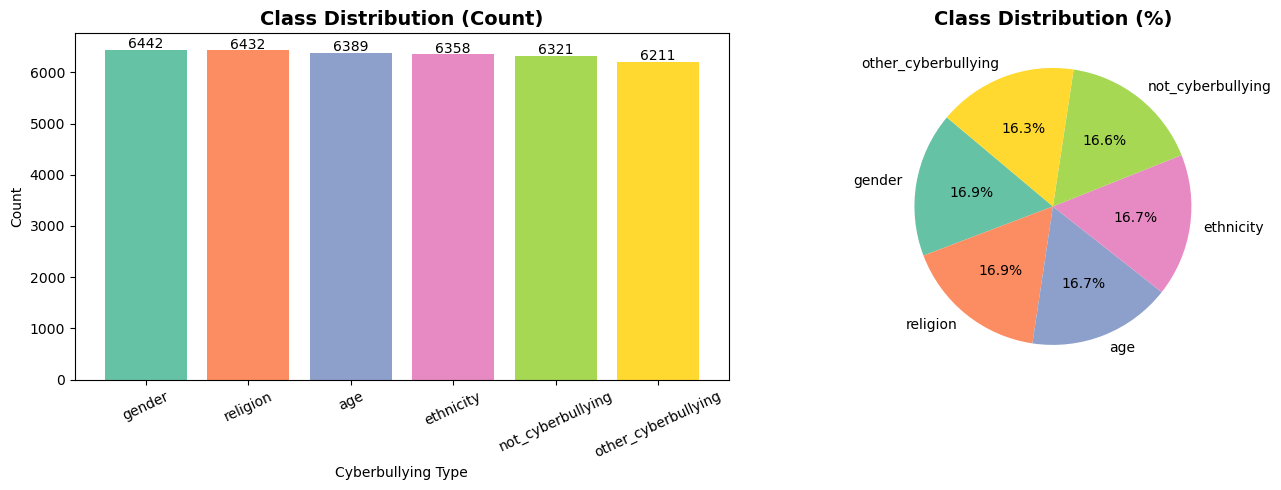


⚠️  Dataset is mildly imbalanced — will handle with class_weight + SMOTE


In [7]:
print("=" * 50)
print("Class Distribution")
print("=" * 50)
class_counts = df['cyberbullying_type'].value_counts()
print(class_counts)
print(f"\nImbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cyberbullying Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=25)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            startangle=140, colors=colors)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n⚠️  Dataset is mildly imbalanced — will handle with class_weight + SMOTE")

Tweet Length Stats:
       tweet_length  word_count
count      38153.00    38153.00
mean         136.22       23.70
std           84.08       15.27
min            1.00        1.00
25%           78.00       13.00
50%          124.00       20.00
75%          179.00       32.00
max         4962.00      790.00


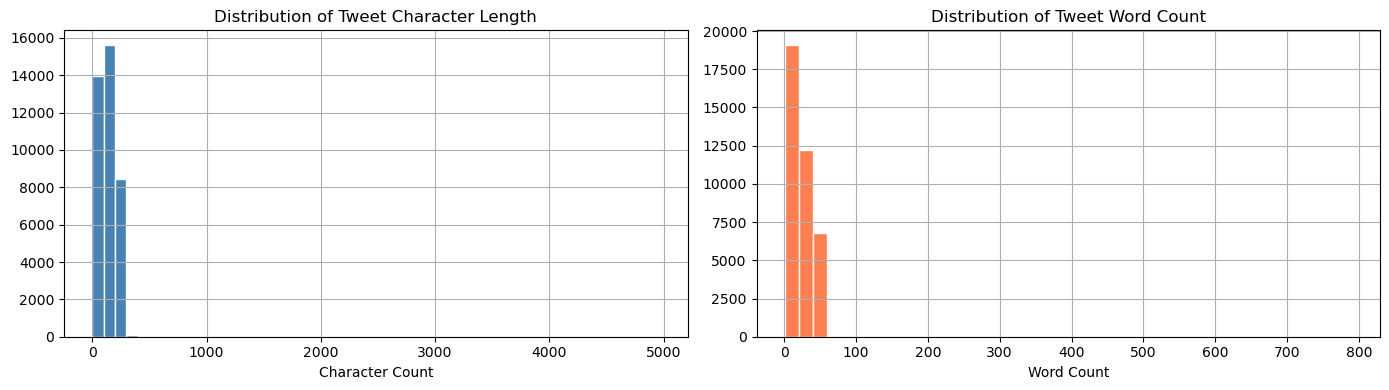

In [8]:
df['tweet_length'] = df['tweet_text'].astype(str).apply(len)
df['word_count']   = df['tweet_text'].astype(str).apply(lambda x: len(x.split()))

print("Tweet Length Stats:")
print(df[['tweet_length', 'word_count']].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df['tweet_length'].hist(bins=50, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Tweet Character Length')
axes[0].set_xlabel('Character Count')

df['word_count'].hist(bins=40, color='coral', edgecolor='white', ax=axes[1])
axes[1].set_title('Distribution of Tweet Word Count')
axes[1].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🧹 3. Text Preprocessing

In [10]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep a small set of negation words — important for cyberbullying sentiment
negation_words = {'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}
stop_words -= negation_words

def preprocess_text(text):
    """Full preprocessing pipeline for tweets."""
    if not isinstance(text, str):
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. Remove @mentions
    text = re.sub(r'@\w+', '', text)

    # 4. Remove hashtag symbol but keep the word
    text = re.sub(r'#(\w+)', r'\1', text)

    # 5. Remove HTML entities
    text = re.sub(r'&[a-z]+;', ' ', text)

    # 6. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 7. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 8. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Tokenize, remove stopwords, lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    return ' '.join(tokens)

print("Preprocessing tweets...")
df['clean_text'] = df['tweet_text'].astype(str).apply(preprocess_text)
print(f"✅ Done! Processed {len(df)} tweets.")

# Show before/after
print("\n--- Before / After Sample ---")
for i in [0, 5, 10]:
    print(f"\n[{df['cyberbullying_type'].iloc[i]}]")
    print(f"  BEFORE: {df['tweet_text'].iloc[i][:120]}")
    print(f"  AFTER : {df['clean_text'].iloc[i][:120]}")

Preprocessing tweets...
✅ Done! Processed 38153 tweets.

--- Before / After Sample ---

[age]
  BEFORE: i hate ppl from high school y’all used to bully me and now that i’m ~hot~ it’s “omg i love your makeup where did you get
  AFTER : hate ppl high school y’all used bully i’m hot it’s “omg love makeup get ring wanna go sometime” fuck

[gender]
  BEFORE: @BreaNichole89 @RapeIsntOkay and no I haven't made gay jokes or rape jokes what's funny about rape?
  AFTER : no havent made gay joke rape joke whats funny rape

[not_cyberbullying]
  BEFORE: This will be my absolute last day in a skirt. #80Today :D
  AFTER : absolute last day skirt today


In [11]:
# Drop rows where clean_text became empty after preprocessing
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Removed {before - len(df)} empty rows after preprocessing. Remaining: {len(df)}")

Removed 242 empty rows after preprocessing. Remaining: 37911


---
## 🏷️ 4. Label Encoding & Train/Test Split

In [13]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['cyberbullying_type'])

print("Label Mapping:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {idx} → {cls}")

X = df['clean_text']
y = df['label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {len(X_train_raw)}  |  Test size: {len(X_test_raw)}")
print("Train class distribution:")
print(pd.Series(y_train).map(dict(enumerate(le.classes_))).value_counts())

Label Mapping:
  0 → age
  1 → ethnicity
  2 → gender
  3 → not_cyberbullying
  4 → other_cyberbullying
  5 → religion

Train size: 30328  |  Test size: 7583
Train class distribution:
label
religion               5145
gender                 5140
age                    5111
ethnicity              5086
not_cyberbullying      4982
other_cyberbullying    4864
Name: count, dtype: int64


---
## 🔢 5. TF-IDF Vectorization

In [15]:
tfidf = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1, 2),       # unigrams + bigrams
    sublinear_tf=True,         # dampens frequency (log scaling)
    min_df=2,                  # ignore very rare terms
    max_df=0.95,               # ignore very common terms
    analyzer='word',
    strip_accents='unicode'
)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print(f"TF-IDF Feature Matrix Shape:")
print(f"  Train: {X_train_tfidf.shape}")
print(f"  Test : {X_test_tfidf.shape}")

TF-IDF Feature Matrix Shape:
  Train: (30328, 30000)
  Test : (7583, 30000)


---
## ⚖️ 6. Handle Class Imbalance with SMOTE

In [17]:
print("Applying SMOTE to balance training classes...")
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)

print(f"\nBefore SMOTE — Train shape: {X_train_tfidf.shape}")
print(f"After  SMOTE — Train shape: {X_train_sm.shape}")

print("\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_sm, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c}")

Applying SMOTE to balance training classes...

Before SMOTE — Train shape: (30328, 30000)
After  SMOTE — Train shape: (30870, 30000)

Class distribution after SMOTE:
  age: 5145
  ethnicity: 5145
  gender: 5145
  not_cyberbullying: 5145
  other_cyberbullying: 5145
  religion: 5145


---
## 🤖 7. Model Training & Evaluation

### Models:
1. **Logistic Regression** — strong baseline for text classification  
2. **Random Forest** — ensemble tree, handles non-linearity  
3. **Multinomial Naive Bayes** — classic text classification model  
4. **Gradient Boosting (sklearn)** — powerful boosting, no external dependency  

In [19]:
results = {}

def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    """Train, evaluate, and store results for a model."""
    print(f"\n{'='*60}")
    print(f"  Model: {name}")
    print(f"{'='*60}")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wt   = f1_score(y_test, y_pred, average='weighted')

    print(f"  Accuracy       : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  F1 (macro)     : {f1_mac:.4f}")
    print(f"  F1 (weighted)  : {f1_wt:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    results[name] = {
        'model'   : model,
        'accuracy': acc,
        'f1_macro': f1_mac,
        'f1_weighted': f1_wt,
        'y_pred'  : y_pred
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=30)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return model

### 7.1 Logistic Regression


  Model: Logistic Regression
  Accuracy       : 0.8249 (82.49%)
  F1 (macro)     : 0.8235
  F1 (weighted)  : 0.8265

  Classification Report:
                     precision    recall  f1-score   support

                age       0.96      0.97      0.97      1278
          ethnicity       0.98      0.99      0.98      1271
             gender       0.91      0.85      0.88      1285
  not_cyberbullying       0.57      0.55      0.56      1246
other_cyberbullying       0.57      0.64      0.60      1216
           religion       0.96      0.94      0.95      1287

           accuracy                           0.82      7583
          macro avg       0.83      0.82      0.82      7583
       weighted avg       0.83      0.82      0.83      7583



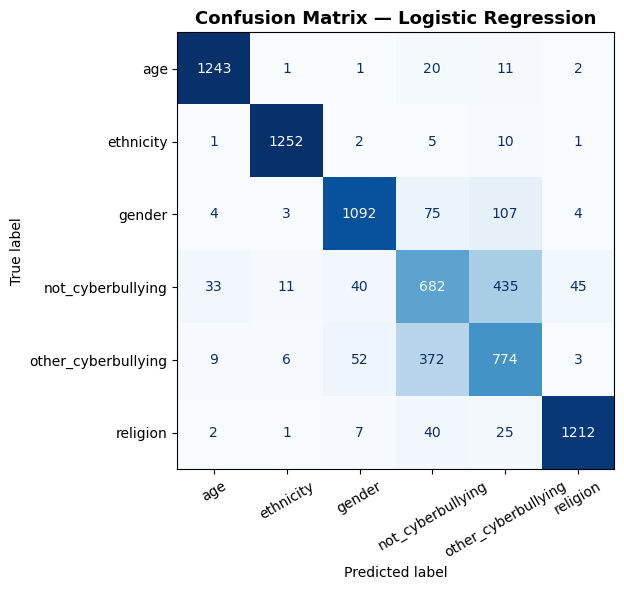

LogisticRegression(C=5.0, class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)

In [21]:
lr = LogisticRegression(
    C=5.0,
    max_iter=1000,
    solver='lbfgs',
   # multi_class='multinomial',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
evaluate_model('Logistic Regression', lr, X_train_sm, y_train_sm, X_test_tfidf, y_test)

### 7.2 Random Forest


  Model: Random Forest
  Accuracy       : 0.6980 (69.80%)
  F1 (macro)     : 0.6644
  F1 (weighted)  : 0.6776

  Classification Report:
                     precision    recall  f1-score   support

                age       0.80      0.85      0.82       175
          ethnicity       0.86      0.89      0.87       156
             gender       0.87      0.70      0.77       186
  not_cyberbullying       0.40      0.71      0.51       162
other_cyberbullying       0.32      0.08      0.13       148
           religion       0.86      0.88      0.87       173

           accuracy                           0.70      1000
          macro avg       0.68      0.69      0.66      1000
       weighted avg       0.70      0.70      0.68      1000



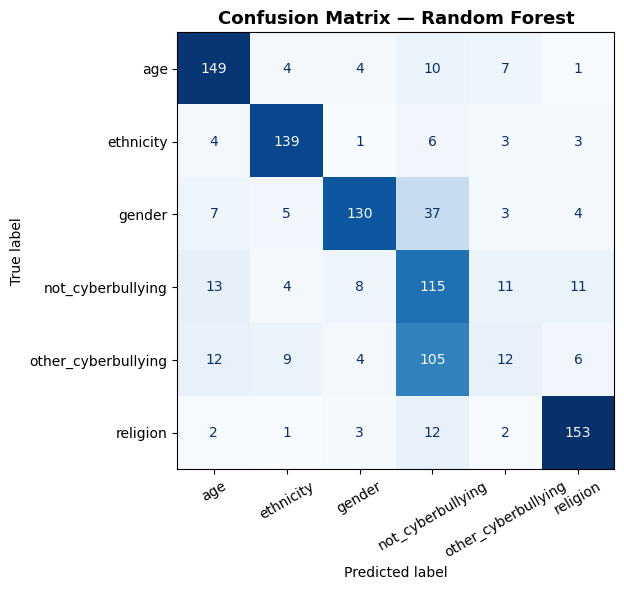

RandomForestClassifier(max_depth=10, n_estimators=20, n_jobs=-1,
                       random_state=42)

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Use small sample for faster training
X_small = X_train_sm[:3000]
y_small = y_train_sm[:3000]

# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=20,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

evaluate_model('Random Forest',rf,X_small,y_small,X_test_tfidf[:1000],y_test[:1000])

### 7.3 Multinomial Naive Bayes


  Model: Multinomial NB
  Accuracy       : 0.7721 (77.21%)
  F1 (macro)     : 0.7592
  F1 (weighted)  : 0.7621

  Classification Report:
                     precision    recall  f1-score   support

                age       0.80      0.97      0.88      1278
          ethnicity       0.90      0.93      0.91      1271
             gender       0.86      0.79      0.82      1285
  not_cyberbullying       0.58      0.43      0.49      1246
other_cyberbullying       0.56      0.54      0.55      1216
           religion       0.84      0.96      0.90      1287

           accuracy                           0.77      7583
          macro avg       0.76      0.77      0.76      7583
       weighted avg       0.76      0.77      0.76      7583



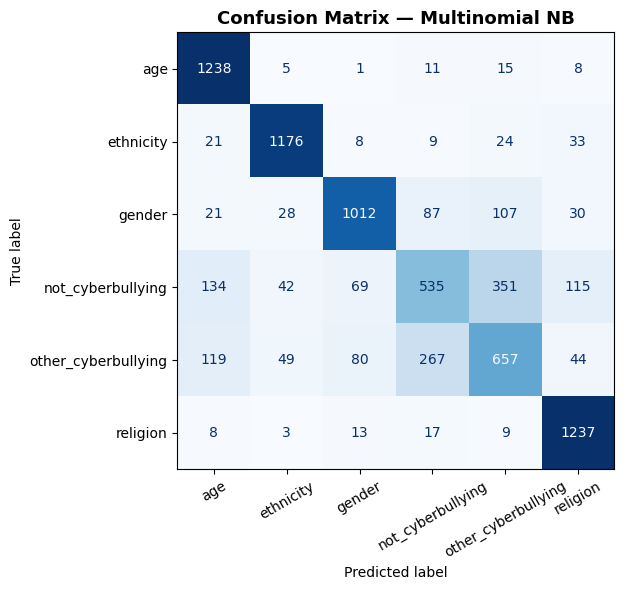

MultinomialNB(alpha=0.1)

In [25]:
# Note: MultinomialNB requires non-negative features.
# SMOTE can produce negative values on sparse TF-IDF; clip to 0.
from scipy.sparse import csr_matrix
X_train_nb = csr_matrix(X_train_sm.copy())
X_train_nb.data = np.clip(X_train_nb.data, 0, None)

nb = MultinomialNB(alpha=0.1)
evaluate_model('Multinomial NB', nb, X_train_nb, y_train_sm, X_test_tfidf, y_test)

### 7.4 Gradient Boosting Classifier


  Model: Gradient Boosting
  Accuracy       : 0.7890 (78.90%)
  F1 (macro)     : 0.7845
  F1 (weighted)  : 0.7896

  Classification Report:
                     precision    recall  f1-score   support

                age       0.94      0.98      0.96       175
          ethnicity       0.98      0.96      0.97       156
             gender       0.98      0.69      0.81       186
  not_cyberbullying       0.67      0.35      0.46       162
other_cyberbullying       0.46      0.93      0.62       148
           religion       0.95      0.84      0.89       173

           accuracy                           0.79      1000
          macro avg       0.83      0.79      0.78      1000
       weighted avg       0.84      0.79      0.79      1000



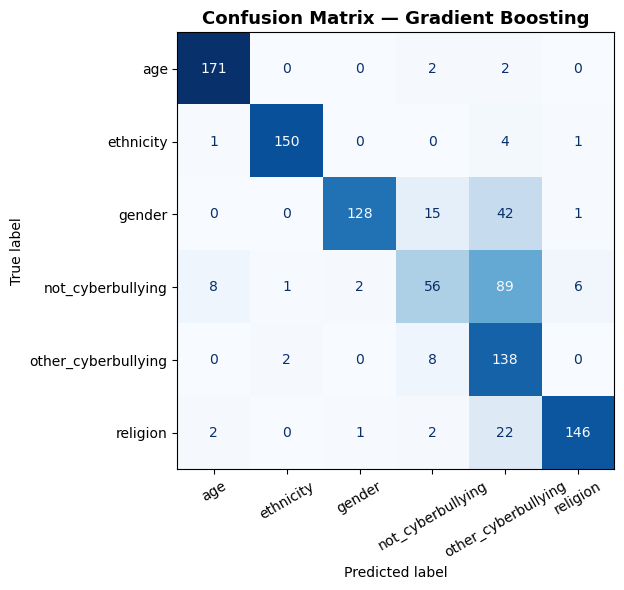

GradientBoostingClassifier(n_estimators=10, random_state=42)

In [27]:
from sklearn.ensemble import GradientBoostingClassifier

# Use only small sample for fast training
X_small = X_train_sm[:3000].toarray()
y_small = y_train_sm[:3000]

gb = GradientBoostingClassifier(
    n_estimators=10,
    random_state=42
)

evaluate_model(
    'Gradient Boosting',gb,X_small,y_small,X_test_tfidf[:1000].toarray(),y_test[:1000])

---
## 📊 8. Compare All Models


           MODEL COMPARISON SUMMARY
              Model  Accuracy  F1 (Macro)  F1 (Weighted)
Logistic Regression  0.824871    0.823464       0.826458
  Gradient Boosting  0.789000    0.784460       0.789645
     Multinomial NB  0.772122    0.759245       0.762141
      Random Forest  0.698000    0.664433       0.677640


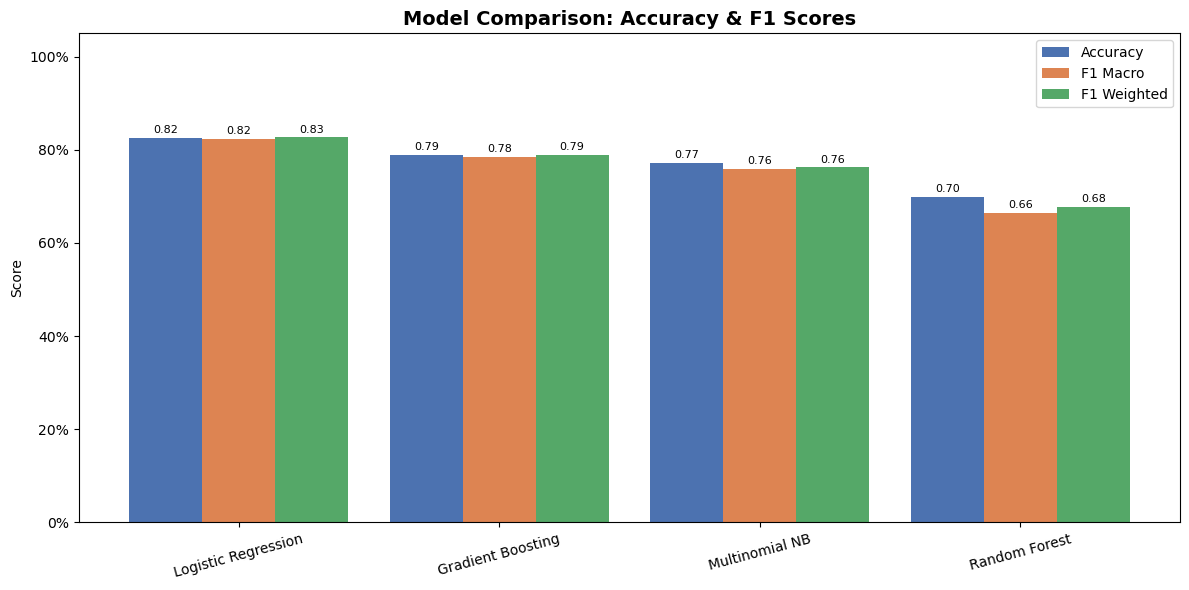

In [29]:
comparison_df = pd.DataFrame({
    'Model'       : list(results.keys()),
    'Accuracy'    : [results[m]['accuracy']    for m in results],
    'F1 (Macro)'  : [results[m]['f1_macro']    for m in results],
    'F1 (Weighted)': [results[m]['f1_weighted'] for m in results],
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("\n" + "="*65)
print("           MODEL COMPARISON SUMMARY")
print("="*65)
print(comparison_df.to_string(index=False))
print("="*65)

# Plot
x = np.arange(len(comparison_df))
width = 0.28
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, comparison_df['Accuracy'],     width, label='Accuracy',     color='#4C72B0')
ax.bar(x,          comparison_df['F1 (Macro)'],  width, label='F1 Macro',     color='#DD8452')
ax.bar(x + width,  comparison_df['F1 (Weighted)'],width,label='F1 Weighted',  color='#55A868')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison: Accuracy & F1 Scores', fontsize=14, fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 9. Hyperparameter Tuning — Best Model (GridSearchCV)

In [31]:
best_name = comparison_df.iloc[0]['Model']
print(f"🏆 Best Model: {best_name}")
print(f"   Accuracy   : {comparison_df.iloc[0]['Accuracy']:.4f}")
print(f"   F1 (Macro) : {comparison_df.iloc[0]['F1 (Macro)']:.4f}")

🏆 Best Model: Logistic Regression
   Accuracy   : 0.8249
   F1 (Macro) : 0.8235


In [32]:
# GridSearchCV tuning for the best model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

if best_name == 'Logistic Regression':
    param_grid = {
        'C'      : [1.0, 5.0, 10.0],
        'solver' : ['saga'],
        'max_iter': [10000]
    }
    base_model = LogisticRegression(
        class_weight='balanced', random_state=42, n_jobs=-1
    )

elif best_name == 'Random Forest':
    param_grid = {
        'n_estimators'    : [200, 300],
        'max_depth'       : [None, 50],
        'min_samples_leaf': [1, 2]
    }
    base_model = RandomForestClassifier(
        class_weight='balanced_subsample', random_state=42, n_jobs=-1
    )

elif best_name == 'Multinomial NB':
    param_grid = {'alpha': [0.05, 0.1, 0.5, 1.0]}
    base_model = MultinomialNB()

else:  # Hist Gradient Boosting
    param_grid = {
        'max_iter'       : [150, 200],
        'learning_rate'  : [0.05, 0.1],
        'max_leaf_nodes' : [31, 63]
    }
    base_model = HistGradientBoostingClassifier(
        class_weight='balanced', random_state=42
    )

print(f"\nRunning GridSearchCV for {best_name}...")
print(f"Parameter Grid: {param_grid}")

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_sm, y_train_sm)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"   Best CV F1 (macro): {grid_search.best_score_:.4f}")


Running GridSearchCV for Logistic Regression...
Parameter Grid: {'C': [1.0, 5.0, 10.0], 'solver': ['saga'], 'max_iter': [10000]}
Fitting 5 folds for each of 3 candidates, totalling 15 fits

✅ Best Parameters: {'C': 1.0, 'max_iter': 10000, 'solver': 'saga'}
   Best CV F1 (macro): 0.8246


In [33]:
# Evaluate tuned model on test set
best_tuned = grid_search.best_estimator_
y_pred_tuned = best_tuned.predict(X_test_tfidf)

acc_tuned    = accuracy_score(y_test, y_pred_tuned)
f1_mac_tuned = f1_score(y_test, y_pred_tuned, average='macro')
f1_wt_tuned  = f1_score(y_test, y_pred_tuned, average='weighted')

print("\n" + "="*55)
print(f"  TUNED {best_name} — Test Set Results")
print("="*55)
print(f"  Accuracy       : {acc_tuned:.4f} ({acc_tuned*100:.2f}%)")
print(f"  F1 (Macro)     : {f1_mac_tuned:.4f}")
print(f"  F1 (Weighted)  : {f1_wt_tuned:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=le.classes_))

# Before vs After tuning
orig_acc = results[best_name]['accuracy']
print(f"  Accuracy before tuning: {orig_acc:.4f}")
print(f"  Accuracy after  tuning: {acc_tuned:.4f}  (Δ {(acc_tuned-orig_acc)*100:+.2f}%)")


  TUNED Logistic Regression — Test Set Results
  Accuracy       : 0.8317 (83.17%)
  F1 (Macro)     : 0.8300
  F1 (Weighted)  : 0.8327

Classification Report:
                     precision    recall  f1-score   support

                age       0.95      0.98      0.96      1278
          ethnicity       0.98      0.98      0.98      1271
             gender       0.93      0.84      0.88      1285
  not_cyberbullying       0.61      0.54      0.57      1246
other_cyberbullying       0.58      0.69      0.63      1216
           religion       0.95      0.94      0.95      1287

           accuracy                           0.83      7583
          macro avg       0.83      0.83      0.83      7583
       weighted avg       0.84      0.83      0.83      7583

  Accuracy before tuning: 0.8249
  Accuracy after  tuning: 0.8317  (Δ +0.69%)


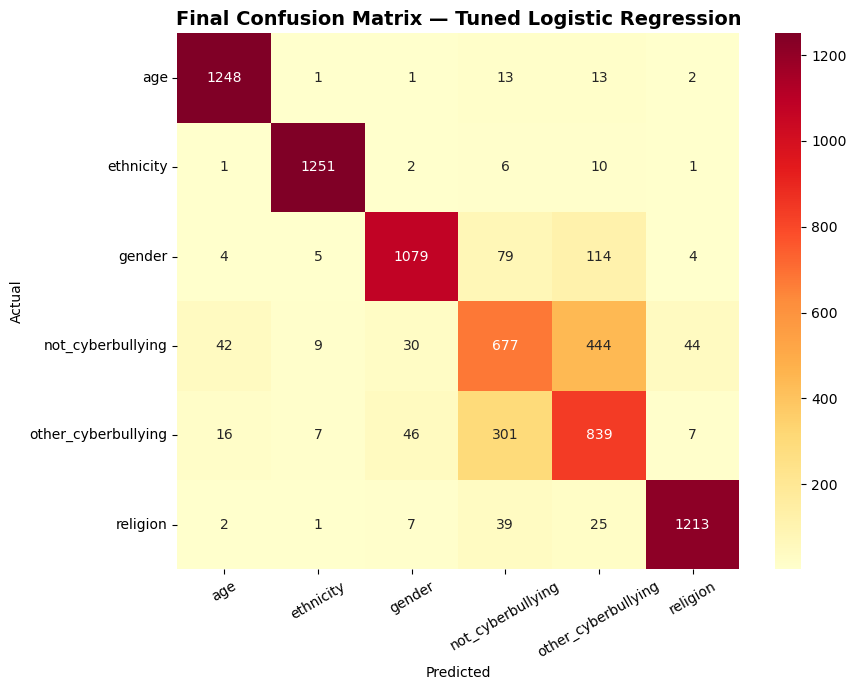

In [34]:
cm_final = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Final Confusion Matrix — Tuned {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💾 10. Save Best Model & Artifacts

In [36]:
# Save TF-IDF vectorizer
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# Save Label Encoder
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save best tuned model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_tuned, f)

# Save model metadata
metadata = {
    'best_model_name': best_name,
    'best_params': grid_search.best_params_,
    'accuracy': acc_tuned,
    'f1_macro': f1_mac_tuned,
    'f1_weighted': f1_wt_tuned,
    'classes': le.classes_.tolist()
}
import json
with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✅ Saved:")
print("   • best_model.pkl")
print("   • tfidf_vectorizer.pkl")
print("   • label_encoder.pkl")
print("   • model_metadata.json")

✅ Saved:
   • best_model.pkl
   • tfidf_vectorizer.pkl
   • label_encoder.pkl
   • model_metadata.json


---
## 🧪 11. Quick Inference Test

In [38]:
def predict_cyberbullying(text):
    """Predict cyberbullying type for a given tweet."""
    cleaned = preprocess_text(text)
    vec = tfidf.transform([cleaned])
    pred = best_tuned.predict(vec)[0]
    label = le.inverse_transform([pred])[0]

    if hasattr(best_tuned, 'predict_proba'):
        proba = best_tuned.predict_proba(vec)[0]
        proba_dict = dict(zip(le.classes_, proba))
        sorted_proba = sorted(proba_dict.items(), key=lambda x: x[1], reverse=True)
        print(f"\nInput : {text[:80]}")
        print(f"Label : {label.upper()}")
        print("Probabilities:")
        for cls, prob in sorted_proba:
            bar = '█' * int(prob * 30)
            print(f"  {cls:<22} {bar:<30} {prob*100:.1f}%")
    else:
        print(f"Input : {text[:80]}")
        print(f"Label : {label.upper()}")

    return label

test_tweets = [
    "You are so ugly because of your skin color, go back to your country",
    "Happy birthday! Hope you have a great day!",
    "Old people should not be allowed to use the internet, they are useless",
    "Women should stay in the kitchen and not have opinions",
    "Your religion is stupid and your god is fake",
    "I don't think you're completely wrong, but the way you explained it was confusing and not very clear",
     "Go back to your country",
    "I really appreciate your help",
    "Old people are useless",
    "High school people are always wrong",
    "Nigga are always dumb",
    "you are sexist and idiot"
]

print("\n" + "="*65)
print("  INFERENCE EXAMPLES")
print("="*65)
for tweet in test_tweets:
    predict_cyberbullying(tweet)
    print("-"*65)


  INFERENCE EXAMPLES

Input : You are so ugly because of your skin color, go back to your country
Label : OTHER_CYBERBULLYING
Probabilities:
  other_cyberbullying    ████████                       29.6%
  not_cyberbullying      ███████                        26.1%
  ethnicity              █████                          18.6%
  religion               ███                            10.6%
  gender                 ██                             8.7%
  age                    █                              6.4%
-----------------------------------------------------------------

Input : Happy birthday! Hope you have a great day!
Label : NOT_CYBERBULLYING
Probabilities:
  not_cyberbullying      ████████████████               56.3%
  other_cyberbullying    ███████                        26.3%
  ethnicity              █                              5.2%
  religion               █                              4.9%
  gender                 █                              4.6%
  age                 

---
## ✅ 12. Final Summary

In [40]:
print("\n" + "🔴" * 30)
print("          CYBERBULLYING NLP PROJECT — FINAL SUMMARY")
print("🔴" * 30)
print(f"\n📦 Dataset       : {len(df):,} tweets | 6 classes")
print(f"🔢 TF-IDF Feats  : {X_train_tfidf.shape[1]:,} features (unigram + bigram)")
print(f"⚖️  Imbalance     : Handled with SMOTE + class_weight")
print(f"\n📊 All Models Tested:")
for _, row in comparison_df.iterrows():
    marker = "🏆" if row['Model'] == best_name else "  "
    print(f"  {marker}  {row['Model']:<25}  Acc: {row['Accuracy']*100:.2f}%  F1: {row['F1 (Macro)']:.4f}")
print(f"\n🏆 Best Model      : {best_name}")
print(f"   Best Params     : {grid_search.best_params_}")
print(f"   Final Accuracy  : {acc_tuned*100:.2f}%")
print(f"   F1 (Macro)      : {f1_mac_tuned:.4f}")
print(f"   F1 (Weighted)   : {f1_wt_tuned:.4f}")
print(f"\n💾 Saved Artifacts  : best_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl")
print("\n✅ Ready for Streamlit deployment!")


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
          CYBERBULLYING NLP PROJECT — FINAL SUMMARY
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

📦 Dataset       : 37,911 tweets | 6 classes
🔢 TF-IDF Feats  : 30,000 features (unigram + bigram)
⚖️  Imbalance     : Handled with SMOTE + class_weight

📊 All Models Tested:
  🏆  Logistic Regression        Acc: 82.49%  F1: 0.8235
      Gradient Boosting          Acc: 78.90%  F1: 0.7845
      Multinomial NB             Acc: 77.21%  F1: 0.7592
      Random Forest              Acc: 69.80%  F1: 0.6644

🏆 Best Model      : Logistic Regression
   Best Params     : {'C': 1.0, 'max_iter': 10000, 'solver': 'saga'}
   Final Accuracy  : 83.17%
   F1 (Macro)      : 0.8300
   F1 (Weighted)   : 0.8327

💾 Saved Artifacts  : best_model.pkl, tfidf_vectorizer.pkl, label_encoder.pkl

✅ Ready for Streamlit deployment!


---
## 🚀 13. Streamlit App — `app.py`

Run the cell below to generate the Streamlit app file, then launch it with:
```bash
streamlit run app.py
```